In [1]:
import pandas as pd
import numpy as np

from gpcam import GPOptimizer

import matplotlib.pyplot as plt
import plotly.graph_objects as go

import mrcfile

from scipy.spatial.distance import cdist

# Loading the Data

In [ ]:
# Crop the metadata bar at the bottom
def load_sem_image(path, crop_bottom=60, target_size=(128, 128)):
    img = Image.open(path).convert('L')
    W, H = img.size
    img  = img.crop((0, 0, W, H - crop_bottom))  # remove metadata bar
    img  = img.resize(target_size, Image.LANCZOS)
    return np.array(img, dtype=np.float64)


load_sem_image

In [ ]:
# rho = np.zeros((50, 128, 128, 128), dtype=np.float32) # 100, 128,128,128
# for i in range(50): # 100
#     fname = f'128_org/{i:03d}.mrc'  # formats as 000, 001, 002, etc.
#     with mrcfile.open(fname, permissive=True) as mrc:
#         rho[i] = mrc.data

# angles = np.linspace(0.0, 180.0, 50, endpoint=True) # 360, 100, endpoint=False

# # # Mapping the angles from 0 to 180 then 18 to 0
# # def circular_angle_diff(angle1, angle2):
# #     """Calculate minimum angular difference on a circle (0-180 degrees)"""
# #     diff = abs(angle1 - angle2)
# #     return np.minimum(diff, 360 - diff)


In [3]:
angles

array([  0.        ,   3.67346939,   7.34693878,  11.02040816,
        14.69387755,  18.36734694,  22.04081633,  25.71428571,
        29.3877551 ,  33.06122449,  36.73469388,  40.40816327,
        44.08163265,  47.75510204,  51.42857143,  55.10204082,
        58.7755102 ,  62.44897959,  66.12244898,  69.79591837,
        73.46938776,  77.14285714,  80.81632653,  84.48979592,
        88.16326531,  91.83673469,  95.51020408,  99.18367347,
       102.85714286, 106.53061224, 110.20408163, 113.87755102,
       117.55102041, 121.2244898 , 124.89795918, 128.57142857,
       132.24489796, 135.91836735, 139.59183673, 143.26530612,
       146.93877551, 150.6122449 , 154.28571429, 157.95918367,
       161.63265306, 165.30612245, 168.97959184, 172.65306122,
       176.32653061, 180.        ])

In [4]:
# # angles_2 = np.empty((100,))
# # for i in range(100):
    
# #     if angles[i]<=180:
# #         angles_2[i] = angles[i]
# #     else:
# #         angles_2[i] = 180 - (angles[i] - 180) 


# angles_2 = np.where(angles <= 180, angles, 360 - angles)
# angles_2

In [5]:


# Get the 3D volume
volume = rho[49]
 
# Create coordinate grids
x, y, z = np.meshgrid(range(128), range(128), range(128), indexing='ij')

# Flatten everything
x_flat = x.flatten()
y_flat = y.flatten()
z_flat = z.flatten()
values_flat = volume.flatten()

# Filter by threshold to avoid plotting all 2M+ points
threshold = 1e-5 # volume.max() * 0.5  # adjust as needed
mask = values_flat > threshold

# Create 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=x_flat[mask],
    y=y_flat[mask],
    z=z_flat[mask],
    mode='markers',
    marker=dict(
        size=4,
        color=values_flat[mask],
        colorscale='plasma',
        showscale=True,
        colorbar=dict(title="Intensity")
    )
)])

fig.update_layout(
    title='3D Scatter Plot of rho[0]',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    width=900,
    height=700
)

fig.show()

In [6]:
# Get the 3D volumes
volume = rho[0]
volume2 = rho[49]
 
# Create coordinate grids
x, y, z = np.meshgrid(range(128), range(128), range(128), indexing='ij')

# Flatten everything
x_flat = x.flatten()
y_flat = y.flatten()
z_flat = z.flatten()
values_flat = volume.flatten()
values_flat2 = volume2.flatten()

# Filter by threshold for both volumes
threshold = 1e-5
mask1 = values_flat > threshold
mask2 = values_flat2 > threshold

# Create 3D scatter plot with both volumes
fig = go.Figure()

# Add first volume
fig.add_trace(go.Scatter3d(
    x=x_flat[mask1],
    y=y_flat[mask1],
    z=z_flat[mask1],
    mode='markers',
    name='rho[0]',
    marker=dict(
        size=4,
        color=values_flat[mask1],
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title="rho[0]", x=1.0)
    )
))

# Add second volume
fig.add_trace(go.Scatter3d(
    x=x_flat[mask2],
    y=y_flat[mask2],
    z=z_flat[mask2],
    mode='markers',
    name='rho[50]',
    marker=dict(
        size=4,
        color=values_flat2[mask2],
        colorscale='Plasma',  # Different colorscale
        showscale=True,
        colorbar=dict(title="rho[50]", x=1.15)  # Offset second colorbar
    )
))

fig.update_layout(
    title='3D Scatter Plot of rho[0] and rho[50]',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    width=900,
    height=700
)

fig.show()

# Testing the threshold in order to extract the points of the volume only

In [7]:
# Quick test - compare thresholds
vol1, vol2 = rho[0], rho[10]

for thresh in [0.5, 0.7, 1.0, 1.5]:
    # Count points
    n1 = (vol1 > thresh).sum()
    n2 = (vol2 > thresh).sum()
    print(f"\nThreshold {thresh}: {n1} vs {n2} points")
    
    # If you want to test Wasserstein time
    # (run the sparse function here)


Threshold 0.5: 1838 vs 1902 points

Threshold 0.7: 1312 vs 1355 points

Threshold 1.0: 787 vs 819 points

Threshold 1.5: 156 vs 185 points


(0.0, 1000.0)

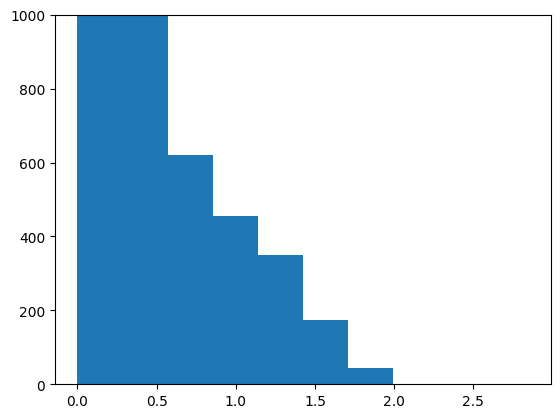

In [8]:
plt.hist(vol1.flatten())
plt.ylim([0,1000])

# Compute Distances between Volumes

In [9]:
# import os
# from scipy.stats import wasserstein_distance
# import ot

# # ===== ADAPTED DISTANCE FUNCTIONS FOR 3D VOLUMES =====

# Cell 1: Imports and Distance Functions

# def JS_divergence_3d(p, q, eps=1e-10):
#     p_safe = np.clip(p, eps, None)
#     q_safe = np.clip(q, eps, None)
#     p_norm = p_safe / p_safe.sum()
#     q_norm = q_safe / q_safe.sum()
#     M = 0.5 * (p_norm + q_norm)
#     kl_pm = np.sum(p_norm * np.log(p_norm / M))
#     kl_qm = np.sum(q_norm * np.log(q_norm / M))
#     js = 0.5 * (kl_pm + kl_qm)
#     return np.maximum(js, 0.0)

# def sliced_wass_3d_ot(volume_futures, i, j, n_projections=50):
#     """
#     Sliced Wasserstein using POT library
#     vol_i and vol_j are actual numpy arrays (futures auto-resolved by Dask)
#     """
    
    
    
#     # Create 3D grid positions
#     positions = np.array([[i, j, k] 
#                          for i in range(128) 
#                          for j in range(128) 
#                          for k in range(128)])

#     vol_i = volume_futures[i]
#     vol_j = volume_futures[j]
    
#     # Flatten and normalize
#     p = vol_i.flatten()
#     q = vol_j.flatten()
#     p = p / p.sum()
#     q = q / q.sum()
    
#     sw_dist = ot.sliced_wasserstein_distance(
#         positions, positions, p, q,
#         n_projections=n_projections, seed=42
#     )
#     return sw_dist


# def wasserstein_subsampled_3d(volume_futures, i, j, n_samples=10000, reg=0.01):
#     """
#     Wasserstein on subsampled points (tractable!)
#     """
#     import ot
#     import numpy as np
    
#     vol_i = volume_futures[i]
#     vol_j = volume_futures[j]
    
#     # Flatten and normalize
#     p_full = vol_i.flatten()
#     q_full = vol_j.flatten()
#     p_full = p_full / p_full.sum()
#     q_full = q_full / q_full.sum()
    
#     # Sample indices proportional to mass
#     np.random.seed(42)
#     idx_i = np.random.choice(len(p_full), size=n_samples, replace=True, p=p_full)
#     idx_j = np.random.choice(len(q_full), size=n_samples, replace=True, p=q_full)
    
#     # Get 3D positions of sampled points
#     positions_all = np.array([[x, y, z] 
#                               for x in range(128) 
#                               for y in range(128) 
#                               for z in range(128)])
    
#     X_i = positions_all[idx_i]
#     X_j = positions_all[idx_j]
    
#     # Uniform weights for samples
#     a = np.ones(n_samples) / n_samples
#     b = np.ones(n_samples) / n_samples
    
#     # Distance matrix (now only 10k x 10k)
#     M = ot.dist(X_i, X_j, metric='euclidean')
#     M /= M.max()
    
#     # Sinkhorn on subsampled points
#     wass_dist = ot.sinkhorn2(a, b, M, reg=reg)
    
#     return wass_dist

    
# def wasserstein_sinkhorn_subsampled_3d(volume_futures, i, j, n_samples=10000, reg=0.01):
#     """
#     Sinkhorn-Wasserstein on subsampled points - TRACTABLE!
#     """
#     import ot
#     import numpy as np
    
#     vol_i = volume_futures[i]
#     vol_j = volume_futures[j]
    
#     # Flatten and normalize
#     p_full = vol_i.flatten()
#     q_full = vol_j.flatten()
#     p_full = p_full / (p_full.sum() + 1e-12)
#     q_full = q_full / (q_full.sum() + 1e-12)
    
#     # Sample 10k points proportional to mass
#     np.random.seed(42 + i * 1000 + j)
#     idx_i = np.random.choice(len(p_full), size=n_samples, replace=True, p=p_full)
#     idx_j = np.random.choice(len(q_full), size=n_samples, replace=True, p=q_full)
    
#     # Get 3D coordinates of sampled points
#     positions = np.array([[x, y, z] 
#                           for x in range(128) 
#                           for y in range(128) 
#                           for z in range(128)])
    
#     X_i = positions[idx_i].astype(np.float32)
#     X_j = positions[idx_j].astype(np.float32)
    
#     # Uniform weights
#     a = np.ones(n_samples, dtype=np.float32) / n_samples
#     b = np.ones(n_samples, dtype=np.float32) / n_samples
    
#     # Distance matrix: 10k x 10k = 400 MB (tractable!)
#     M = ot.dist(X_i, X_j, metric='sqeuclidean')
#     M = M / (M.max() + 1e-10)
    
#     # Sinkhorn
#     wass_dist = ot.sinkhorn2(a, b, M, reg=reg, numItermax=1000)
    
#     return float(wass_dist)


# def wasserstein_sparse_3d(volume_futures, i, j, threshold=0.5, reg=0.01):
#     """
#     Exact Wasserstein on bright dots (intensity > 0.5)
#     ~1900 points per volume - captures full dot structure
#     """
#     import ot
#     import numpy as np
    
#     vol_i = volume_futures[i]
#     vol_j = volume_futures[j]
    
#     # Extract bright points
#     mask_i = vol_i > threshold
#     mask_j = vol_j > threshold
    
#     # 3D positions
#     positions_all = np.array([[x, y, z] 
#                              for x in range(128) 
#                              for y in range(128) 
#                              for z in range(128)])
    
#     X_i = positions_all[mask_i.ravel()].astype(np.float32)
#     X_j = positions_all[mask_j.ravel()].astype(np.float32)
    
#     # Intensities as weights
#     w_i = vol_i.ravel()[mask_i.ravel()].astype(np.float32)
#     w_j = vol_j.ravel()[mask_j.ravel()].astype(np.float32)
    
#     # Normalize
#     w_i = w_i / w_i.sum()
#     w_j = w_j / w_j.sum()
    
#     # Distance matrix
#     M = ot.dist(X_i, X_j, metric='euclidean')
#     M = M / (M.max() + 1e-10)
    
#     # Sinkhorn
#     wass_dist = ot.sinkhorn2(w_i, w_j, M, reg=reg, numItermax=1000)
    
#     return float(wass_dist)

# # ===== COMPUTE DISTANCE MATRICES =====

# # Recommended: Start with the fastest metrics
# distance_metrics = {
#     'JS': JS_divergence_3d,
#     # 'sliced_Wass': sliced_wasserstein_3d,
#     # 'GW': gromov_wasserstein_3d,  # WARNING: EXTREMELY slow for 128^3!
# }

# for name, func in distance_metrics.items():
#     print(f"\n{'='*70}")
    
#     filename = f'volumes_distance_{name}.npy'
    
#     # Check if file already exists
#     if os.path.exists(filename):
#         print(f"⏭️  SKIPPING {name}: {filename} already exists")
#         D = np.load(filename)
#         print(f"   Loaded existing file - Shape: {D.shape}")
#         print(f"   Min: {np.min(D):.6f}, Max: {np.max(D):.6f}")
#     else:
#         # Compute the distance matrix
#         D = compute_distance_matrix(rho, func, name=name)
        
#         # Save it
#         np.save(filename, D)
        
#         print(f"✅ Saved: {filename}")
#         print(f"   Shape: {D.shape}")
#         print(f"   Min: {np.min(D):.6f}, Max: {np.max(D):.6f}")

# # Save angles (only if not already saved)
# angles_file = 'angles.npy'
# if os.path.exists(angles_file):
#     print(f"\n⏭️  SKIPPING: {angles_file} already exists")
# else:
#     np.save(angles_file, angles)
#     print(f"\n✅ Saved: {angles_file}")

In [9]:
from sklearn.model_selection import train_test_split

# ===== LOAD PRECOMPUTED MATRICES =====
print("="*70)
print("Loading precomputed data and distances")
print("="*70)

# Choose which distance metric to use
DISTANCE_METRIC = 'sliced_Wass'  # Options: 'JS', 'sliced_Wass', 'sinkhorn', 'Wass'

distance_full = np.load(f'volumes_distance_{DISTANCE_METRIC}.npy')
#angles = np.load('angles.npy')

print(f"✅ Loaded {DISTANCE_METRIC} distance matrix: {distance_full.shape}")
print(f"✅ Loaded angles: {angles.shape}")

# ===== SPLIT INTO TRAIN/TEST =====
print("\n" + "="*70)
print("Splitting into train/test")
print("="*70)

# Split indices (0 to 99 for the 100 volumes)
indices = np.arange(len(angles))  # 0 to 99
train_idx_unsorted, test_idx_unsorted = train_test_split(
    indices, 
    test_size=0.2, 
    random_state= 747 # 4525#, 42
)

# Sort indices to preserve original order
train_idx = np.sort(train_idx_unsorted)
test_idx = np.sort(test_idx_unsorted)


# Filter test indices to only keep those within train range
min_train = np.min(train_idx)
max_train = np.max(train_idx)

# Keep only test indices within [min_train, max_train]
mask = (test_idx >= min_train) & (test_idx <= max_train)
test_idx_filtered = test_idx[mask]

print(f"🔍 Train range: [{min_train}, {max_train}]")
print(f"✂️  Removed {len(test_idx) - len(test_idx_filtered)} test points outside train range")
print(f"✅ Filtered test indices: {test_idx_filtered[:10]}...")
print(f"✅ Final test size: {len(test_idx_filtered)}")

# Extract train and test angles using filtered indices
y_train = angles[train_idx]
y_test = angles[test_idx_filtered]

# Use the sorted indices as "features" for GP
X_train = train_idx.reshape(-1, 1)  # Shape: (n_train, 1)
X_test = test_idx_filtered.reshape(-1, 1)    # Shape: (n_test_filtered, 1)


Loading precomputed data and distances
✅ Loaded sliced_Wass distance matrix: (100, 100)
✅ Loaded angles: (50,)

Splitting into train/test
🔍 Train range: [0, 49]
✂️  Removed 0 test points outside train range
✅ Filtered test indices: [ 4  7  9 15 17 25 40 42 43 46]...
✅ Final test size: 10


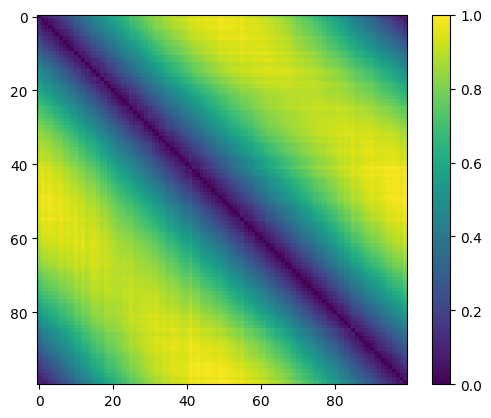

In [10]:
plt.imshow(distance_full/np.max(distance_full))
plt.colorbar()

# Plotting Variogram

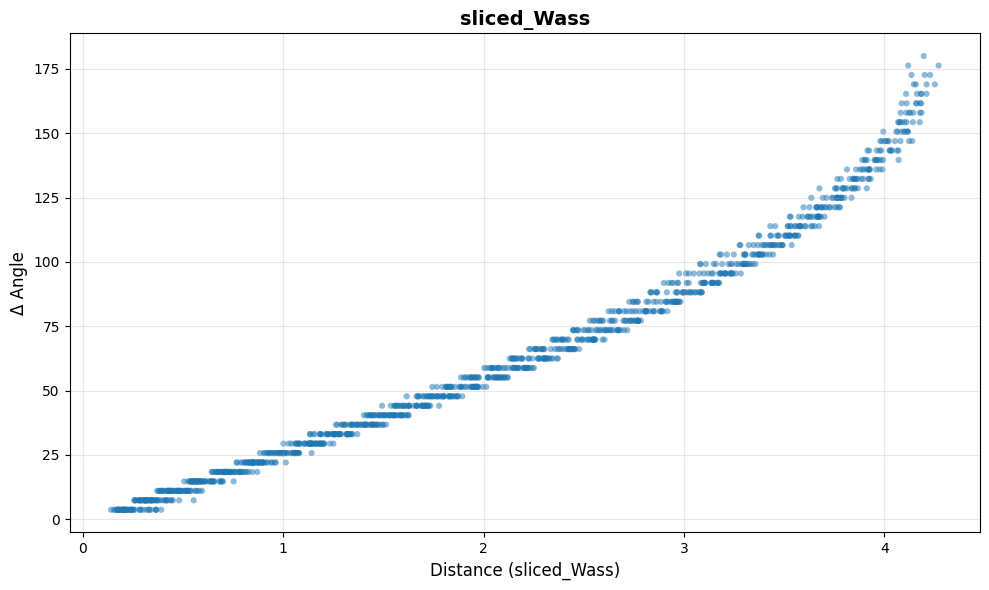

Total number of pairs: 1225
Distance range: [0.1400, 4.2713]
Angle difference range: [0, 180.0000]


In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Extract distances for training data pairs
n = 100
delta_y = []
distances = []

for i in range(len(angles)):
    for j in range(i+1, len(angles)):
        # Simple absolute difference (no need for circular logic anymore!)
        delta_y.append(abs(angles[i] - angles[j]))
        distances.append(distance_full[i, j])

delta_y = np.array(delta_y)
distances = np.array(distances)


# Plot variogram: distance vs angle difference
plt.figure(figsize=(10, 6))
plt.scatter(distances, delta_y, alpha=0.5, s=20, edgecolors='none')
plt.xlabel(f'Distance ({DISTANCE_METRIC})', fontsize=12)
plt.ylabel('Δ Angle', fontsize=12)
plt.title(f'{DISTANCE_METRIC}', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total number of pairs: {len(distances)}")
print(f"Distance range: [{np.min(distances):.4f}, {np.max(distances):.4f}]")
print(f"Angle difference range: [0, {np.max(delta_y):.4f}]")

In [13]:
# Variogram when we map the angles 0 - 180 then 180 -0

# Extract distances for training data pairs
n = 100
distances = []
delta_y = []

for i in range(n):
    for j in range(i + 1, n):
        # Get distance from precomputed matrix
        dist = distance_full[i, j]
        distances.append(dist)
        
        # Get circular angle difference
        angle_diff = circular_angle_diff(angles[i], angles[j])
        delta_y.append(angle_diff)

distances = np.array(distances)
delta_y = np.array(delta_y)

# Plot variogram: distance vs angle difference
plt.figure(figsize=(10, 6))
plt.scatter(distances, delta_y, alpha=0.5, s=20, edgecolors='none')
plt.xlabel(f'Distance ({DISTANCE_METRIC})', fontsize=12)
plt.ylabel('Δ Angle (degrees)', fontsize=12)
plt.title(f'Variogram: Distance vs Circular Angle Difference - {DISTANCE_METRIC}', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.ylim(0, 180)  # Circular differences range from 0 to 180
plt.tight_layout()
plt.show()

print(f"Total number of pairs: {len(distances)}")
print(f"Distance range: [{np.min(distances):.4f}, {np.max(distances):.4f}]")
print(f"Angle difference range: [0, {np.max(delta_y):.4f}] (should be ≤180)")

NameError: name 'circular_angle_diff' is not defined

# GP Model

In [14]:
# Step 2: Define the basic GP components

def bump(d, r, beta, ampl):
    """
    Bump function for the kernel
    d: distances (can be any shape)
    r: radius parameter. Identifies the cutoff after which the covariance becomes 0 when beta=0
    beta: shape parameter. 0 results in a square-like function, larger values cause faster decay
    ampl: amplitude
    """
    a = 1.0 - (d**2 / r**2)
    bump_values = np.zeros_like(a)
    
    # Only compute where a > 0
    positive_mask = a > 0.0
    if np.any(positive_mask):
        #beta = 0.1
        e = np.exp((-beta / a[positive_mask]) + beta)
        bump_values[positive_mask] = ampl * e
    
    return bump_values


def bump_k(x1, x2, hps):
    
    # x1 and x2 ARE the indices - just extract them
    x1_idx = x1.astype(int).flatten()
    x2_idx = x2.astype(int).flatten()
    
    d1 = distance_full[np.ix_(x1_idx, train_idx)]  # Shape: (len(x1), n_train)
    d2 = distance_full[np.ix_(x2_idx, train_idx)]  # Shape: (len(x2), n_train)
    
    # Apply bump to create embedding
    # phi_x1[i, :] = embedding of x1[i] based on distances to all training points
    phi_x1 = bump(d1, hps[1], beta=1, ampl=1.0)  # Shape: (len(x1), n_train)
    phi_x2 = bump(d2, hps[1], beta=1, ampl=1.0)  # Shape: (len(x2), n_train)
    
    # RBF on embeddings
    D_mat = cdist(phi_x1, phi_x2, metric='euclidean')  # Shape: (len(x1), len(x2))
    
    kernel_matrix = hps[0] * np.exp(-D_mat**2 / hps[2])
    
    return kernel_matrix


def my_noise(x, hps):
    s = np.ones(len(x)) * 1e-2  
    return np.diag(s)

def my_mean(x, hps):
    m = np.ones(len(x)) * hps[3]
    return m

# Running one GP model training

In [15]:
# Now set bounds safely

# 2. Bump radius (hps[1]): [min distance, maximum distance]
train_geodesic = distance_full[np.ix_(X_train.flatten(), X_train.flatten())]
non_zero_dists = train_geodesic[train_geodesic > 0]

# Define hyperparameter bounds
bounds = np.empty((4, 2))
bounds[0] = np.array([1e-2, 1e6])   # 1                                           # sigma_f: signal variance      
bounds[1] = np.array([np.min(non_zero_dists), np.max(non_zero_dists)])       # length_scale: bump radius
#bounds[2] = np.array([0.01, 10 ])# 2                                         # length_scale for RBF on embeddings 
bounds[2] = np.array([0.01 * bounds[1,1], 10 * bounds[1,1]]) 
bounds[3] = np.array([0, 360 ])                                             # mean function offset         

print(f"\nHyperparameter bounds:")
print(f"  Signal variance: [{bounds[0, 0]:.6f}, {bounds[0, 1]:.6f}]")
print(f"  Bump radius:     [{bounds[1, 0]:.6f}, {bounds[1, 1]:.6f}]")
print(f"  RBF length:      [{bounds[2, 0]:.6f}, {bounds[2, 1]:.6f}]")
print(f"  Mean:            [{bounds[3, 0]:.6f}, {bounds[3, 1]:.6f}]")


Hyperparameter bounds:
  Signal variance: [0.010000, 1000000.000000]
  Bump radius:     [0.140043, 4.271329]
  RBF length:      [0.042713, 42.713291]
  Mean:            [0.000000, 360.000000]


In [16]:
# Initial hyperparameters (middle of bounds)
init_hps = np.mean(bounds, axis=1)
print(f"\nInitial hyperparameters: {init_hps}")

my_gpo = GPOptimizer(X_train, y_train,
                     init_hyperparameters=init_hps,
                     kernel_function=bump_k,
                     prior_mean_function=my_mean, 
                     noise_function=my_noise,
                        )

initial_log_likelihood = my_gpo.log_likelihood(init_hps)
print(f"Initial log likelihood: {initial_log_likelihood:.6f}")

# Step 5: Train the GP model
my_gpo.train(hyperparameter_bounds=bounds, init_hyperparameters=init_hps, method='global', max_iter=10000)


# Get optimized hyperparameters
final_hps = my_gpo.get_hyperparameters()
final_ll = my_gpo.log_likelihood(final_hps)
print(f"Final hyperparameters:   {final_hps}")
print(f"Final log likelihood:    {final_ll:.2f}")


Initial hyperparameters: [5.00000005e+05 2.20568627e+00 2.13780019e+01 1.80000000e+02]
Initial log likelihood: -170.388756
Final hyperparameters:   [5.82828682e+03 4.24941429e+00 1.97672084e+00 1.02219226e+02]
Final log likelihood:    -109.71


RMSE: 0.04609107388583802


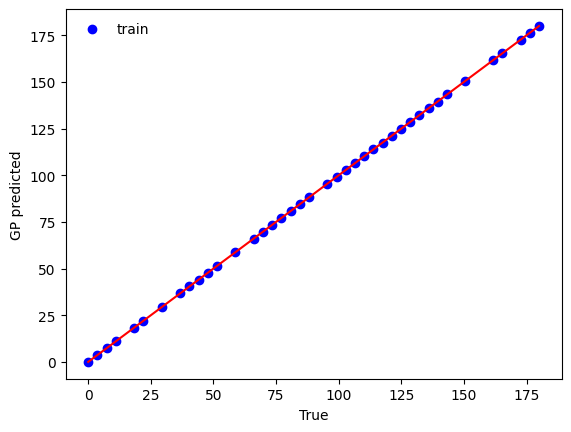

In [17]:
f_train = my_gpo.posterior_mean(X_train)["m(x)"]

my_line = np.linspace(np.min(y_train),np.max(y_train),10)

print('RMSE:', my_gpo.rmse(X_train,y_train)) # *100/np.mean(y_train),'%')

plt.scatter(y_train,f_train,color="blue",label = 'train')
plt.plot(my_line,my_line,c="red")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()

RMSE: 1.6048681852717428


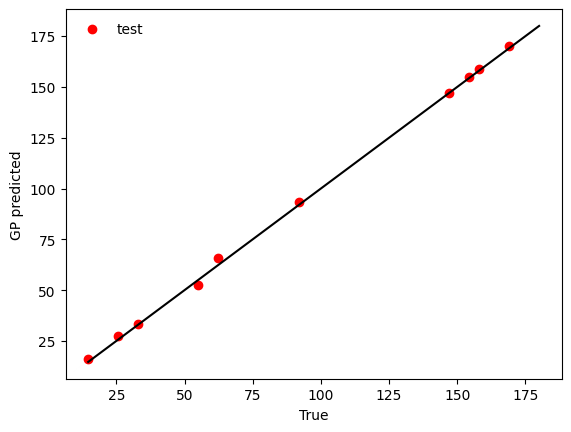

In [18]:
f = my_gpo.posterior_mean(X_test)["m(x)"]
posterior_var = my_gpo.posterior_covariance(X_test, variance_only=True, add_noise=False) # it does not matter if we added noise because it is 1e-6
var = posterior_var["v(x)"].flatten()

print('RMSE:', my_gpo.rmse(X_test,y_test)) # *100/np.mean(y_train),'%')


my_line = np.linspace(np.min(y_test),np.max(y_train),10)

plt.scatter(y_test,f,color="red",label = 'test')
#plt.scatter(y_train,f_train,color="blue",label = 'train')
plt.plot(my_line,my_line,c="black")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()

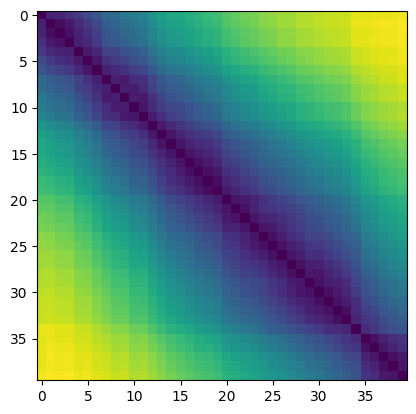

In [19]:
plt.imshow(distance_full[np.ix_(X_train.flatten(), X_train.flatten())])

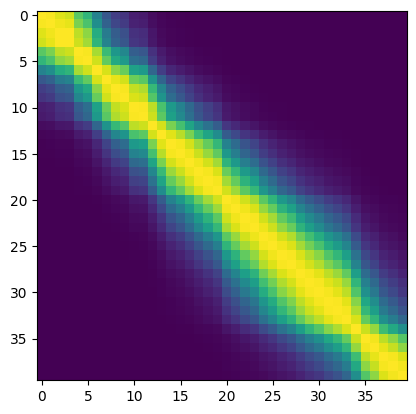

In [20]:
plt.imshow(bump_k(X_train,X_train,my_gpo.get_hyperparameters()))

# Running Multiple trials with different test-train split

In [21]:
import json
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import cdist
from gpcam import GPOptimizer  # Replace with actual import

#all_distance_metrics = ['JS' ,'sliced_Wass_OT_threshold_1e-3','sliced_Wass_OT_threshold_1e-5','sliced_Wass_OT_threshold_0.5','Sinkhorn_OT','Wass_OT_threshold_1e-3','Wass_OT_threshold_1e-5', 'Wass_OT_threshold_0.5']
all_distance_metrics = ['JS' ,'sliced_Wass','sinkhorn','Wass']

all_splitting_ratios = [0.2 , 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]


#angles = np.load('angles.npy')

# Dictionary to store all results
results = {}

# Define this OUTSIDE the loops, at the top of your script
def make_kernel_function(distance_full, train_idx):
    """
    Factory function that creates a kernel function with captured parameters
    """
    def bump(d, r, beta, ampl):
        """Bump function for the kernel"""
        a = 1.0 - (d**2 / r**2)
        bump_values = np.zeros_like(a)
        
        positive_mask = a > 0.0
        if np.any(positive_mask):
            e = np.exp((-beta / a[positive_mask]) + beta)
            bump_values[positive_mask] = ampl * e
        
        return bump_values
    
    def bump_k(x1, x2, hps):
        # x1 and x2 are indices
        x1_idx = x1.astype(int).flatten()
        x2_idx = x2.astype(int).flatten()
        
        # Use the captured values from the outer scope
        d1 = distance_full[np.ix_(x1_idx, train_idx)]
        d2 = distance_full[np.ix_(x2_idx, train_idx)]
        
        phi_x1 = bump(d1, hps[1], beta=1, ampl=1.0)
        phi_x2 = bump(d2, hps[1], beta=1, ampl=1.0)
        
        D_mat = cdist(phi_x1, phi_x2, metric='euclidean')
        
        kernel_matrix = hps[0] * np.exp(-D_mat**2 / hps[2])
        
        return kernel_matrix
    
    return bump_k

for DISTANCE_METRIC in all_distance_metrics:
    print("="*70)
    print(f"Loading precomputed data and distances for {DISTANCE_METRIC}")
    print("="*70)
    
    distance_full = np.load(f'volumes_distance_{DISTANCE_METRIC}.npy')
    
    results[DISTANCE_METRIC] = {}
    
    # Define hyperparameter bounds
    non_zero_dists = distance_full[distance_full > 0]
    bounds = np.empty((4, 2))
    bounds[0] = np.array([1e-2, 1e6])   # 1                                          # sigma_f: signal variance      
    bounds[1] = np.array([np.min(non_zero_dists), np.max(non_zero_dists)])           # length_scale: bump radius
    bounds[2] = np.array([0.01 * bounds[1,1], 10 * bounds[1,1]]) 
    bounds[3] = np.array([0, 360 ])                                                  # mean function offset         
    
    init_hps = np.mean(bounds, axis=1)

    for splitting_ratio in all_splitting_ratios:
        print("\n" + "="*70)
        print(f"Splitting into train/test with test size = {splitting_ratio}")
        print("="*70)
        
        results[DISTANCE_METRIC][str(splitting_ratio)] = []
    
        for split_trial in range(30):
            #print("Splitting trial", split_trial+1)
            
            indices = np.arange(len(angles))
            train_idx_unsorted, test_idx_unsorted = train_test_split(
                indices, 
                test_size=splitting_ratio, 
                random_state=split_trial + int(splitting_ratio * 1000)
            )
            
            train_idx = np.sort(train_idx_unsorted)
            test_idx = np.sort(test_idx_unsorted)
            
            # Filter test indices to only keep those within train range
            min_train = np.min(train_idx)
            max_train = np.max(train_idx)

            # Keep only test indices within [min_train, max_train]
            mask = (test_idx >= min_train) & (test_idx <= max_train)
            test_idx_filtered = test_idx[mask]

            # Extract train and test angles using filtered indices
            y_train = angles[train_idx]
            y_test = angles[test_idx_filtered]   

            # Use the sorted indices as "features" for GP
            X_train = train_idx.reshape(-1, 1)                  # Shape: (n_train, 1)
            X_test = test_idx_filtered.reshape(-1, 1)           # Shape: (n_test_filtered, 1)

            # Create the kernel function with current values
            bump_k = make_kernel_function(distance_full, train_idx)
            
            def my_noise(x, hps):
                s = np.ones(len(x)) * 1e-2  
                return np.diag(s)

            def my_mean(x, hps):
                m = np.ones(len(x)) * hps[3]
                return m
            
            # Train the GP
            my_gpo = GPOptimizer(X_train, y_train,
                                init_hyperparameters=init_hps,
                                kernel_function=bump_k,
                                prior_mean_function=my_mean, 
                                noise_function=my_noise)
            
            my_gpo.train(hyperparameter_bounds=bounds, 
                        init_hyperparameters=init_hps, 
                        method='global')
            
            # print(my_gpo.get_hyperparameters())
            rmse_value = my_gpo.rmse(X_test, y_test)
            print('RMSE:', rmse_value)
            
            results[DISTANCE_METRIC][str(splitting_ratio)].append({
                'trial': split_trial,
                'rmse': float(rmse_value),
                'train_size': len(train_idx),
                'test_size': len(test_idx),
                'train_ratio': 1 - splitting_ratio
            })

# Save results to JSON
with open('New_kernel_RMSEs.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\n" + "="*70)
print("Results saved to New_kernel_RMSEs.json")
print("="*70)

Loading precomputed data and distances for JS

Splitting into train/test with test size = 0.2
RMSE: 0.6756630170688854
RMSE: 0.6741268097154481
RMSE: 0.8746243689302118
RMSE: 0.7526414039153646
RMSE: 0.5387747545209505
RMSE: 0.6799959003350499
RMSE: 0.5469557072038199
RMSE: 0.809775031063931
RMSE: 0.7498803748118357
RMSE: 0.7790899567786562
RMSE: 0.8733034332744383
RMSE: 0.6051993289246285
RMSE: 0.5166205186634906
RMSE: 0.5002151180522869
RMSE: 0.5987874183385516
RMSE: 0.6504632352321079
RMSE: 0.8592159740108946
RMSE: 0.6575742717177594
RMSE: 0.5124740272555094
RMSE: 0.5472477386097984
RMSE: 0.5782004225293499
RMSE: 0.8170488823664371
RMSE: 0.7690418323817853
RMSE: 0.8040549599042472
RMSE: 0.6456492986196402
RMSE: 1.1227989272560523
RMSE: 0.5249767256367911
RMSE: 0.6204855547759407
RMSE: 0.6340091848073778
RMSE: 0.6271704840092333

Splitting into train/test with test size = 0.3
RMSE: 0.5947220283413834
RMSE: 0.7801248635637988
RMSE: 0.44939567813946546
RMSE: 0.6574273611246665
RMSE: 0.

In [22]:
import pandas as pd
import json

# Load results
with open('New_kernel_RMSEs.json', 'r') as f:
    results = json.load(f)

# Flatten the nested structure
data_list = []

for metric in results.keys():
    for split_ratio in results[metric].keys():
        for trial_data in results[metric][split_ratio]:
            data_list.append({
                'distance_metric': metric,
                'test_ratio': float(split_ratio),
                'train_ratio': trial_data['train_ratio'],
                'train_size': trial_data['train_size'],
                'test_size': trial_data['test_size'],
                'trial': trial_data['trial'],
                'rmse': trial_data['rmse']
            })

# Create DataFrame
df = pd.DataFrame(data_list)

df

,distance_metric,test_ratio,train_ratio,train_size,test_size,trial,rmse
0,JS,0.2,0.8,40,10,0,0.675663
1,JS,0.2,0.8,40,10,1,0.674127
2,JS,0.2,0.8,40,10,2,0.874624
3,JS,0.2,0.8,40,10,3,0.752641
4,JS,0.2,0.8,40,10,4,0.538775
...,...,...,...,...,...,...,...
835,Wass,0.8,0.2,10,40,25,1.503278
836,Wass,0.8,0.2,10,40,26,3.366730
837,Wass,0.8,0.2,10,40,27,2.830770
838,Wass,0.8,0.2,10,40,28,2.187704


Loaded results from New_kernel_RMSEs.json


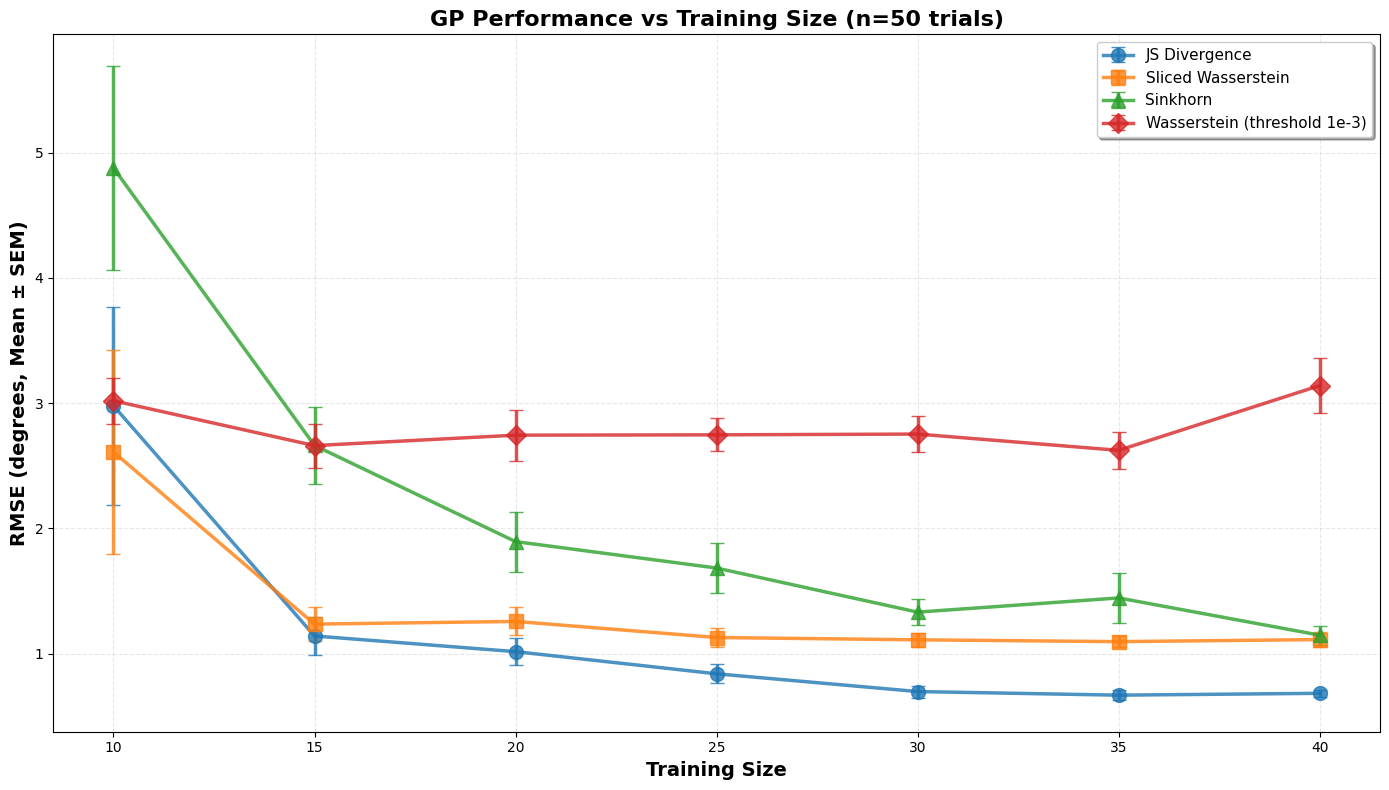


✅ Plot saved: All_metrics_performance.png
📊 Metrics plotted: ['JS', 'sliced_Wass', 'sinkhorn', 'Wass']


In [23]:
import json
import numpy as np
import matplotlib.pyplot as plt

# ==================== LOAD RESULTS ====================

with open('New_kernel_RMSEs.json', 'r') as f:
    results = json.load(f)

print("Loaded results from New_kernel_RMSEs.json")

#all_distance_metrics = ['JS', 'sliced_Wass_OT_threshold_1e-3', 'Sinkhorn_OT', 'Wass_OT_threshold_1e-3','Wass_OT_threshold_1e-5','Wass_OT_threshold_0.5']
all_distance_metrics = ['JS' ,'sliced_Wass','sinkhorn','Wass']

# ==================== PLOTTING ====================

# Compute statistics for plotting
plot_data = {}

for metric in all_distance_metrics:
    if metric not in results:
        print(f"⚠️  Warning: {metric} not found in results, skipping...")
        continue
        
    plot_data[metric] = {
        'train_sizes': [],
        'train_ratios': [],
        'mean_rmse': [],
        'sem_rmse': []
    }
    
    for splitting_ratio_key in sorted(results[metric].keys(), key=float):
        trials = results[metric][splitting_ratio_key]
        rmse_values = [t['rmse'] for t in trials]
        
        plot_data[metric]['train_sizes'].append(trials[0]['train_size'])
        plot_data[metric]['train_ratios'].append(trials[0]['train_ratio'])
        plot_data[metric]['mean_rmse'].append(np.mean(rmse_values))
        plot_data[metric]['sem_rmse'].append(np.std(rmse_values) / np.sqrt(len(rmse_values)))

# Close any existing figures to avoid showing cached plots
plt.close('all')

# Create NEW figure
fig, ax = plt.subplots(figsize=(14, 8))

# Define colors and markers for ALL 5 metrics
colors = {
    'JS': '#1f77b4',                           # Blue
    'sliced_Wass': '#ff7f0e',              # Orange
    'sinkhorn': '#2ca02c',                 # Green
    'Wass': '#d62728',  # Red
    # 'Wass_OT_threshold_1e_5': '#9467bd',     # Purple
    # 'Wass_OT_threshold_0.5': 'blue'
}

markers = {
    'JS': 'o',                                 # Circle
    'sliced_Wass': 's',                    # Square
    'sinkhorn': '^',                       # Triangle up
    'Wass': 'D',     # Diamond
    # 'Wass_OT_threshold_1e_5': 'v',        # Triangle down
    # 'Wass_OT_threshold_0.5': 'o'
}

# Nicer labels for legend
labels = {
    'JS': 'JS Divergence',
    'sliced_Wass': 'Sliced Wasserstein',
    'sinkhorn': 'Sinkhorn',
    'Wass': 'Wasserstein (threshold 1e-3)',
    # 'Wass_OT_threshold_1e-5': 'Wasserstein (threshold 1e-5)',
    # 'Wass_OT_threshold_0.5': 'Wasserstein (threshold 0.5)',
}

for metric in plot_data.keys():
    data = plot_data[metric]
    
    ax.errorbar(data['train_sizes'], 
                 data['mean_rmse'], 
                 yerr=data['sem_rmse'],
                 label=labels[metric],
                 marker=markers[metric],
                 color=colors[metric],
                 capsize=5,
                 linewidth=2.5,
                 markersize=10,
                 alpha=0.8)

ax.set_xlabel('Training Size', fontsize=14, fontweight='bold')
ax.set_ylabel('RMSE (degrees, Mean ± SEM)', fontsize=14, fontweight='bold')
ax.set_title('GP Performance vs Training Size (n=50 trials)', fontsize=16, fontweight='bold')
ax.legend(fontsize=11, frameon=True, shadow=True, loc='best')
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
# plt.savefig('All_metrics_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Plot saved: All_metrics_performance.png")
print(f"📊 Metrics plotted: {list(plot_data.keys())}")

Loaded results from both JSON files
⚠️  Warning: JS not found in Matern kernel results
⚠️  Warning: sinkhorn not found in Matern kernel results
⚠️  Warning: Wass not found in Matern kernel results


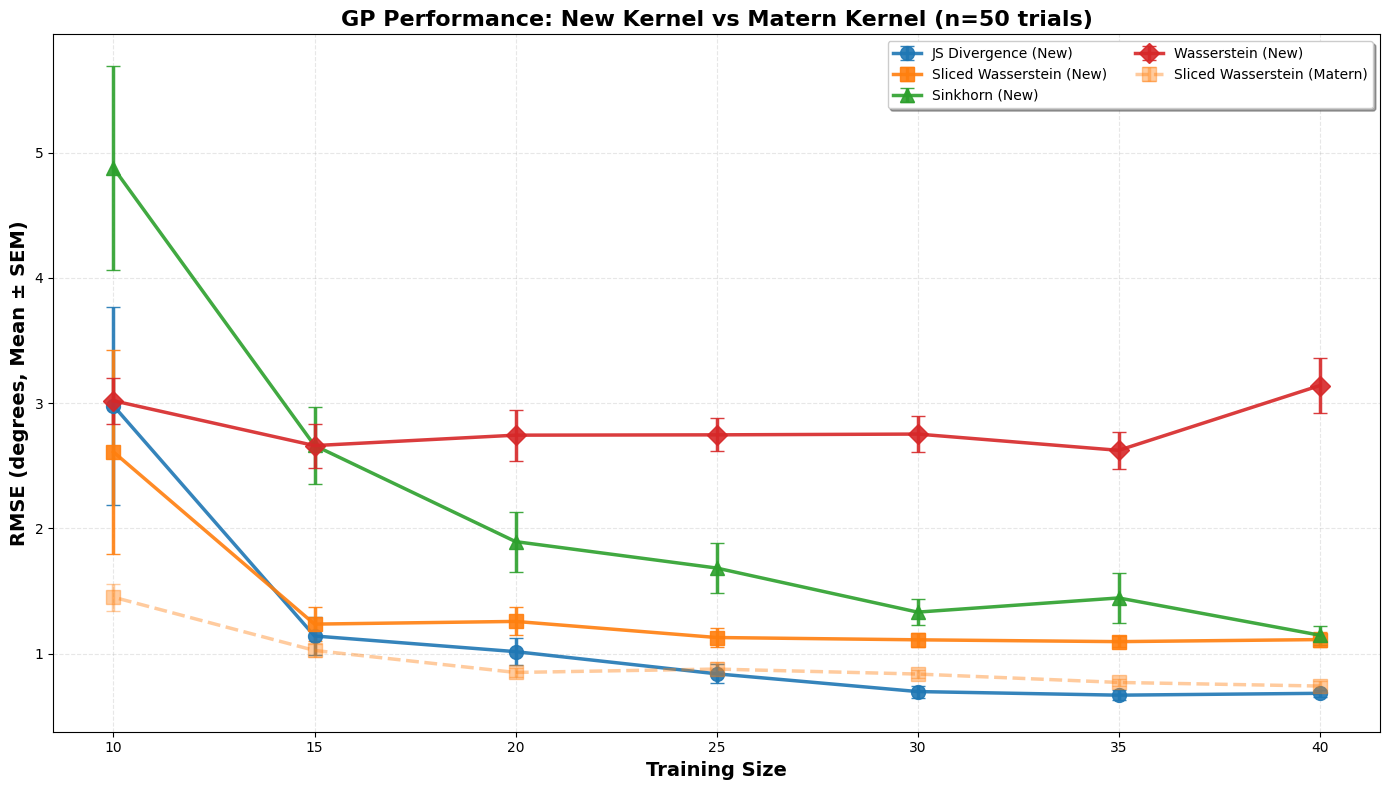


✅ Plot saved: All_kernels_comparison.png
📊 New kernel metrics: ['JS', 'sliced_Wass', 'sinkhorn', 'Wass']
📊 Matern kernel metrics: ['sliced_Wass']


In [25]:
import json
import numpy as np
import matplotlib.pyplot as plt

# ==================== LOAD RESULTS ====================

with open('New_kernel_RMSEs.json', 'r') as f:
    results_new = json.load(f)

with open('Matern_kernel_RMSEs.json', 'r') as f:
    results_matern = json.load(f)

print("Loaded results from both JSON files")

# ==================== PLOTTING ====================

all_distance_metrics = ['JS', 'sliced_Wass', 'sinkhorn', 'Wass']

# Compute statistics for both kernels
plot_data_new = {}
plot_data_matern = {}

for metric in all_distance_metrics:
    # New kernel
    if metric in results_new:
        plot_data_new[metric] = {
            'train_sizes': [],
            'train_ratios': [],
            'mean_rmse': [],
            'sem_rmse': []
        }
        
        for splitting_ratio_key in sorted(results_new[metric].keys(), key=float):
            trials = results_new[metric][splitting_ratio_key]
            rmse_values = [t['rmse'] for t in trials]
            
            plot_data_new[metric]['train_sizes'].append(trials[0]['train_size'])
            plot_data_new[metric]['train_ratios'].append(trials[0]['train_ratio'])
            plot_data_new[metric]['mean_rmse'].append(np.mean(rmse_values))
            plot_data_new[metric]['sem_rmse'].append(np.std(rmse_values) / np.sqrt(len(rmse_values)))
    else:
        print(f"⚠️  Warning: {metric} not found in New kernel results")
    
    # Matern kernel
    if metric in results_matern:
        plot_data_matern[metric] = {
            'train_sizes': [],
            'train_ratios': [],
            'mean_rmse': [],
            'sem_rmse': []
        }
        
        for splitting_ratio_key in sorted(results_matern[metric].keys(), key=float):
            trials = results_matern[metric][splitting_ratio_key]
            rmse_values = [t['rmse'] for t in trials]
            
            plot_data_matern[metric]['train_sizes'].append(trials[0]['train_size'])
            plot_data_matern[metric]['train_ratios'].append(trials[0]['train_ratio'])
            plot_data_matern[metric]['mean_rmse'].append(np.mean(rmse_values))
            plot_data_matern[metric]['sem_rmse'].append(np.std(rmse_values) / np.sqrt(len(rmse_values)))
    else:
        print(f"⚠️  Warning: {metric} not found in Matern kernel results")

# Close any existing figures
plt.close('all')

# Create NEW figure
fig, ax = plt.subplots(figsize=(14, 8))

# Define colors and markers for ALL 5 metrics
colors = {
    'JS': '#1f77b4',                           # Blue
    'sliced_Wass': '#ff7f0e',              # Orange
    'sinkhorn': '#2ca02c',                 # Green
    'Wass': '#d62728',  # Red
    # 'Wass_OT_threshold_1e_5': '#9467bd',     # Purple
    # 'Wass_OT_threshold_0.5': 'blue'
}

markers = {
    'JS': 'o',                                 # Circle
    'sliced_Wass': 's',                    # Square
    'sinkhorn': '^',                       # Triangle up
    'Wass': 'D',     # Diamond
    # 'Wass_OT_threshold_1e_5': 'v',        # Triangle down
    # 'Wass_OT_threshold_0.5': 'o'
}

# Nicer labels for legend
labels = {
    'JS': 'JS Divergence',
    'sliced_Wass': 'Sliced Wasserstein',
    'sinkhorn': 'Sinkhorn',
    'Wass': 'Wasserstein',
    # 'Wass_OT_threshold_1e-5': 'Wasserstein (threshold 1e-5)',
    # 'Wass_OT_threshold_0.5': 'Wasserstein (threshold 0.5)',
}


# Plot New kernel (solid lines, full opacity)
for metric in plot_data_new.keys():
    data = plot_data_new[metric]
    
    ax.errorbar(data['train_sizes'], 
                 data['mean_rmse'], 
                 yerr=data['sem_rmse'],
                 label=f'{labels[metric]} (New)',
                 marker=markers[metric],
                 color=colors[metric],
                 capsize=5,
                 linewidth=2.5,
                 markersize=10,
                 alpha=0.9,
                 linestyle='-')

# Plot Matern kernel (dashed lines, faded)
for metric in plot_data_matern.keys():
    data = plot_data_matern[metric]
    
    ax.errorbar(data['train_sizes'], 
                 data['mean_rmse'], 
                 yerr=data['sem_rmse'],
                 label=f'{labels[metric]} (Matern)',
                 marker=markers[metric],
                 color=colors[metric],
                 capsize=5,
                 linewidth=2.5,
                 markersize=10,
                 alpha=0.4,  # Faded
                 linestyle='--')  # Dashed

ax.set_xlabel('Training Size', fontsize=14, fontweight='bold')
ax.set_ylabel('RMSE (degrees, Mean ± SEM)', fontsize=14, fontweight='bold')
ax.set_title('GP Performance: New Kernel vs Matern Kernel (n=50 trials)', fontsize=16, fontweight='bold')
ax.legend(fontsize=10, frameon=True, shadow=True, loc='best', ncol=2)  # 2 columns for cleaner legend
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
# plt.savefig('All_kernels_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Plot saved: All_kernels_comparison.png")
print(f"📊 New kernel metrics: {list(plot_data_new.keys())}")
print(f"📊 Matern kernel metrics: {list(plot_data_matern.keys())}")